# Calibration Target Detection

In [15]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import pycamcal

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import os
from pprint import pprint
from matplotlib import pyplot as plt
import numpy as np

In [17]:
DATASET_DIR = "./synthetic_calibration_example"
IMAGES_DIR = f"{DATASET_DIR}/dataset/images"
RESULTS_DIR = f"{DATASET_DIR}/results/target_detection"

## Load Images

In [18]:
images = {}

for fname in os.listdir(IMAGES_DIR):
    fpath = f"{IMAGES_DIR}/{fname}"
    print(fpath)

    img = plt.imread(fpath)
    images[fname] = img

image_fnames = list(sorted(images.keys()))

print(f"Loaded {len(images)} images")

./synthetic_calibration_example/dataset/images/image_018.png
./synthetic_calibration_example/dataset/images/image_019.png
./synthetic_calibration_example/dataset/images/image_009.png
./synthetic_calibration_example/dataset/images/image_008.png
./synthetic_calibration_example/dataset/images/image_011.png
./synthetic_calibration_example/dataset/images/image_005.png
./synthetic_calibration_example/dataset/images/image_004.png
./synthetic_calibration_example/dataset/images/image_010.png
./synthetic_calibration_example/dataset/images/image_006.png
./synthetic_calibration_example/dataset/images/image_012.png
./synthetic_calibration_example/dataset/images/image_013.png
./synthetic_calibration_example/dataset/images/image_007.png
./synthetic_calibration_example/dataset/images/image_003.png
./synthetic_calibration_example/dataset/images/image_017.png
./synthetic_calibration_example/dataset/images/image_016.png
./synthetic_calibration_example/dataset/images/image_002.png
./synthetic_calibration_

## Detect Checkerboard Target

In [ ]:
import json

# load calibration target info
with open(f"{DATASET_DIR}/dataset/calibration_target_info.json") as f:
    calibration_target_info = json.load(f)

# compose world-space target feature points
target = CheckerboardTarget(**calibration_target_info["params"])
target

In [21]:
from pycamcal.calibration.targets.checkerboard import CheckerboardTarget
from pycamcal.calibration.targets.viz_utils import plot_target_detection

target_detections = {}

for image_fname in image_fnames:
    image = images[image_fname]

    # detect points
    success, target_points = checkerboard.detect(image)
    print(f"Detected {len(target_points)} features from {image_fname}")

    target_detections[image_fname] = target_points


Detected 54 features from image_000.png
Detected 54 features from image_001.png
Detected 54 features from image_002.png
Detected 54 features from image_003.png
Detected 54 features from image_004.png
Detected 54 features from image_005.png
Detected 54 features from image_006.png
Detected 54 features from image_007.png
Detected 54 features from image_008.png
Detected 54 features from image_009.png
Detected 54 features from image_010.png
Detected 54 features from image_011.png
Detected 54 features from image_012.png
Detected 54 features from image_013.png
Detected 54 features from image_014.png
Detected 54 features from image_015.png
Detected 54 features from image_016.png
Detected 54 features from image_017.png
Detected 54 features from image_018.png
Detected 54 features from image_019.png


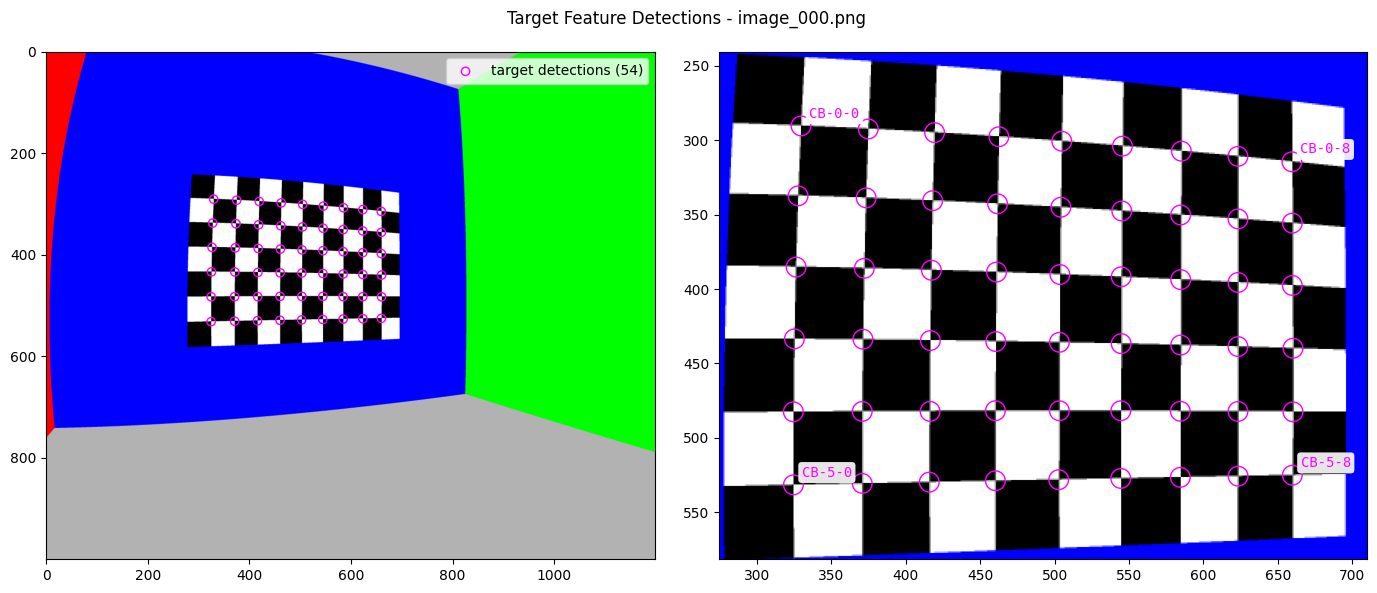

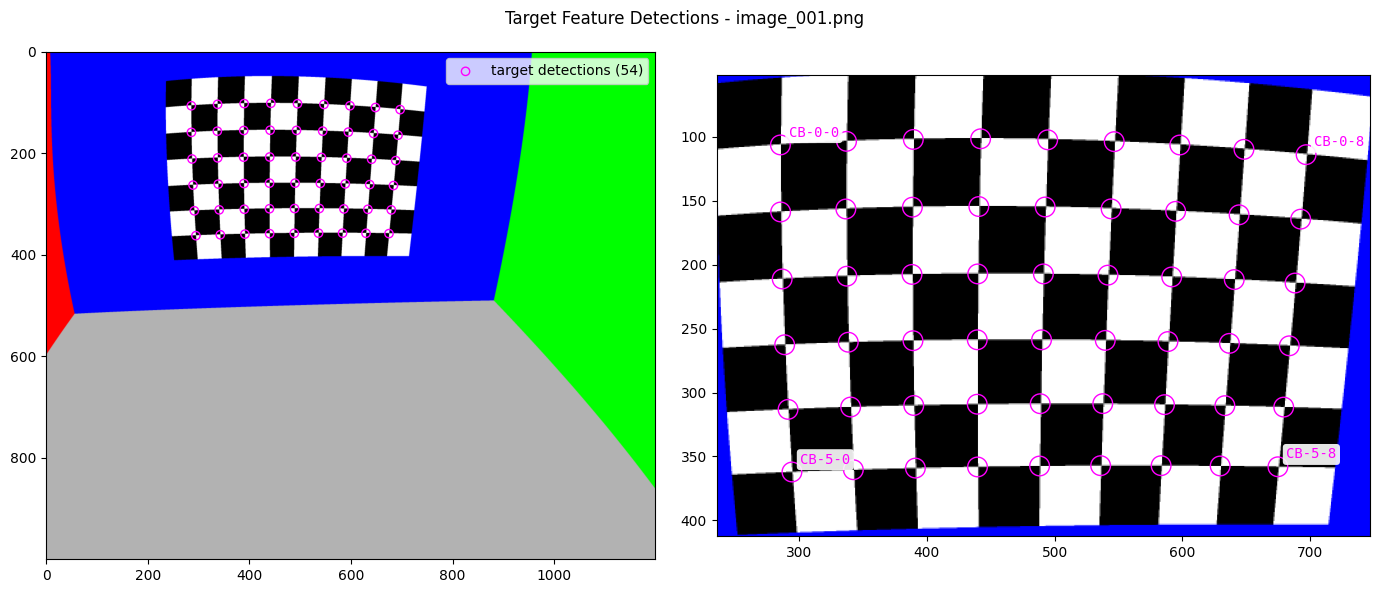

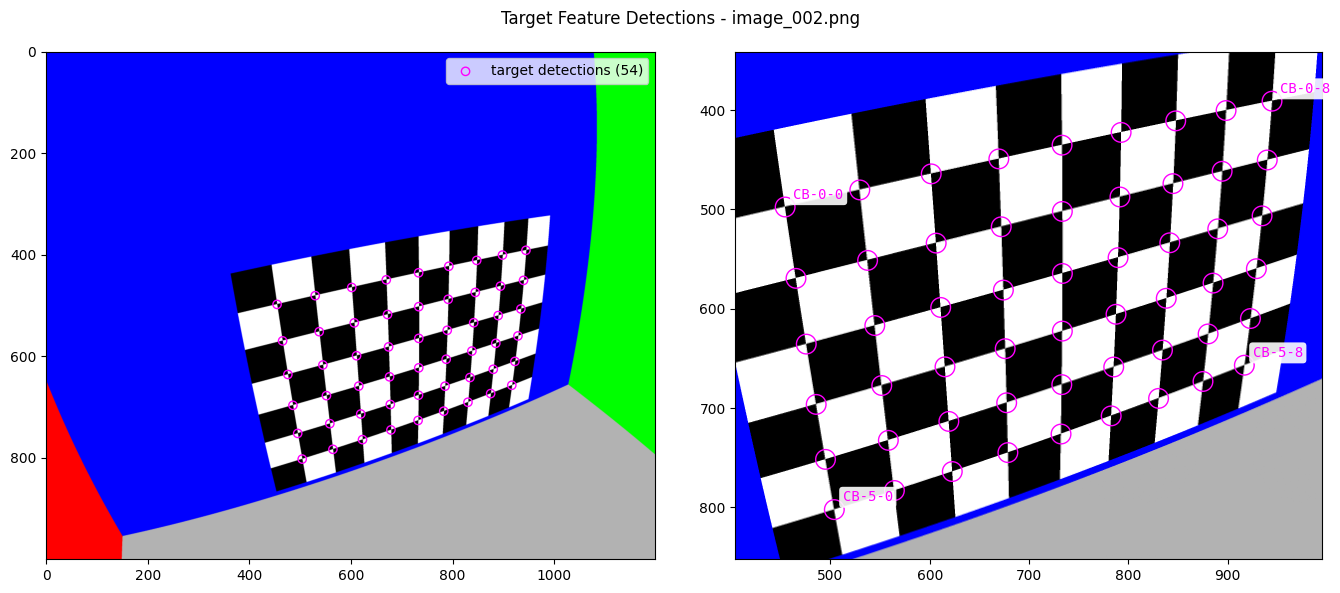

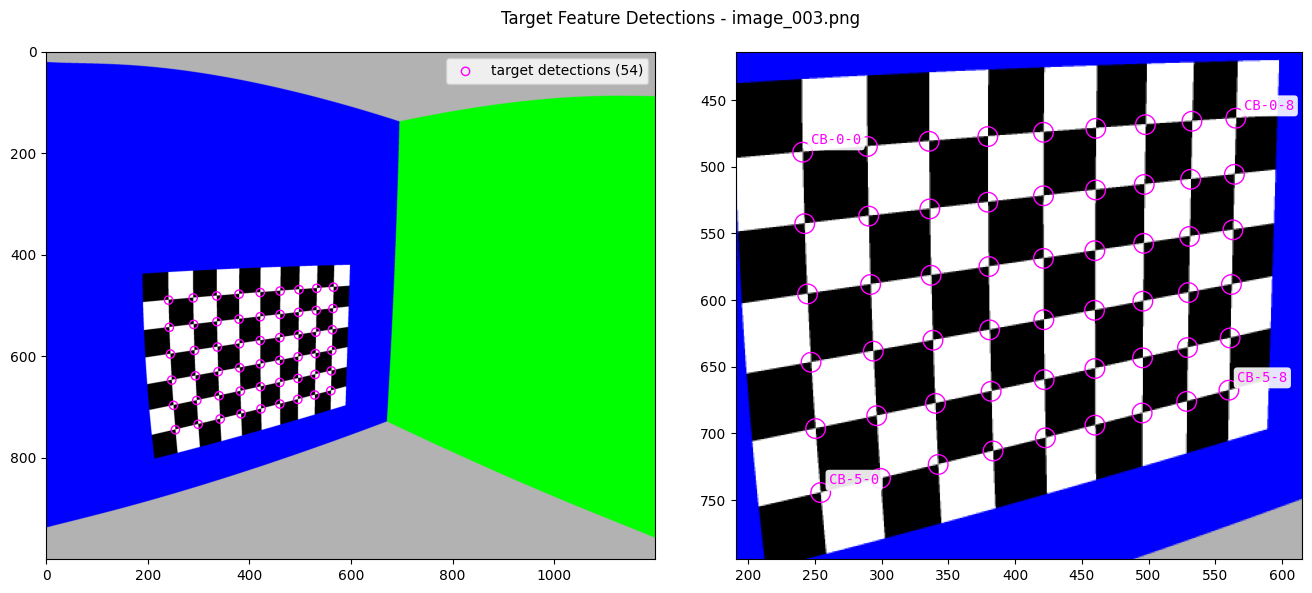

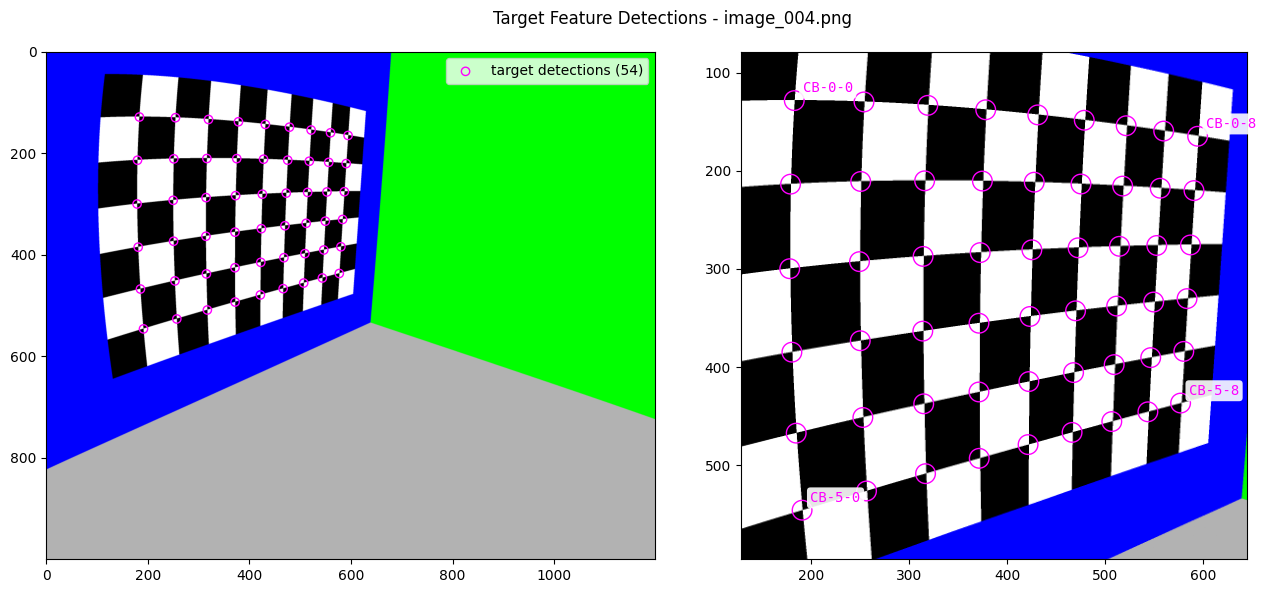

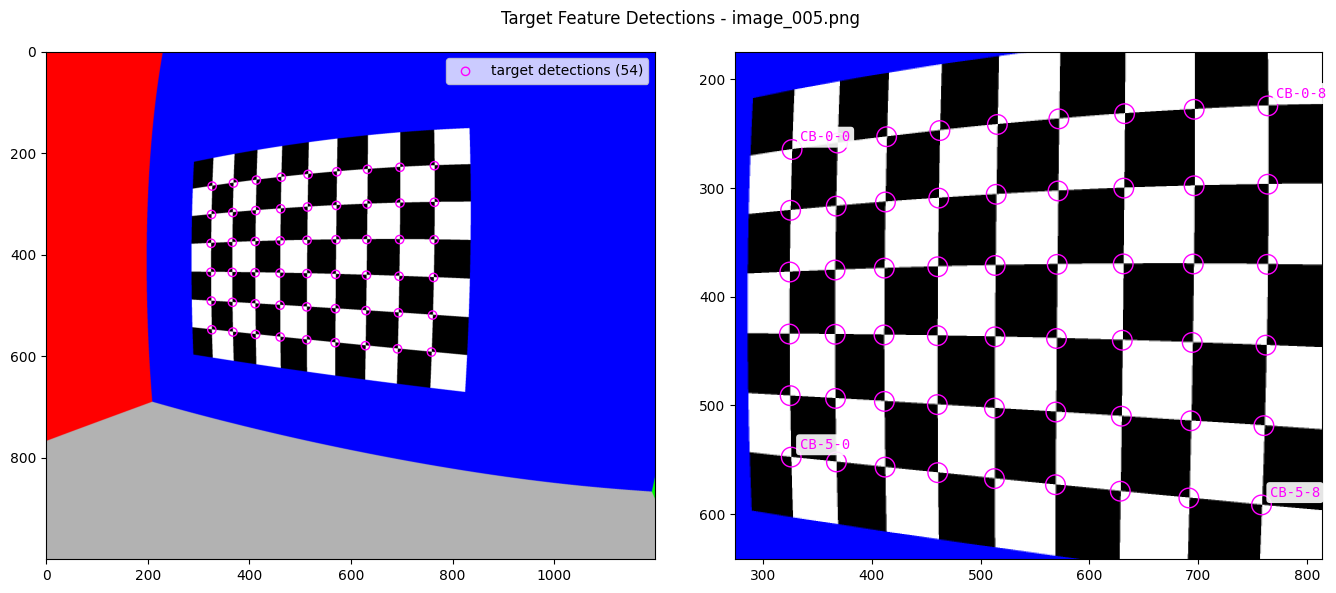

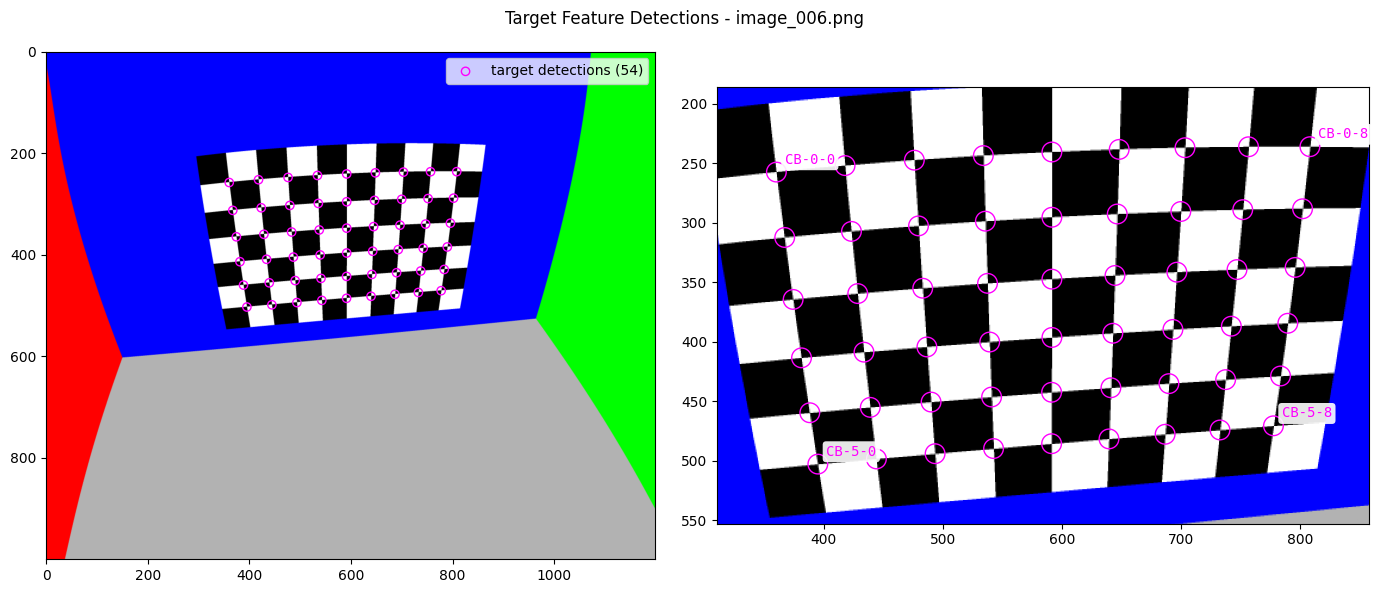

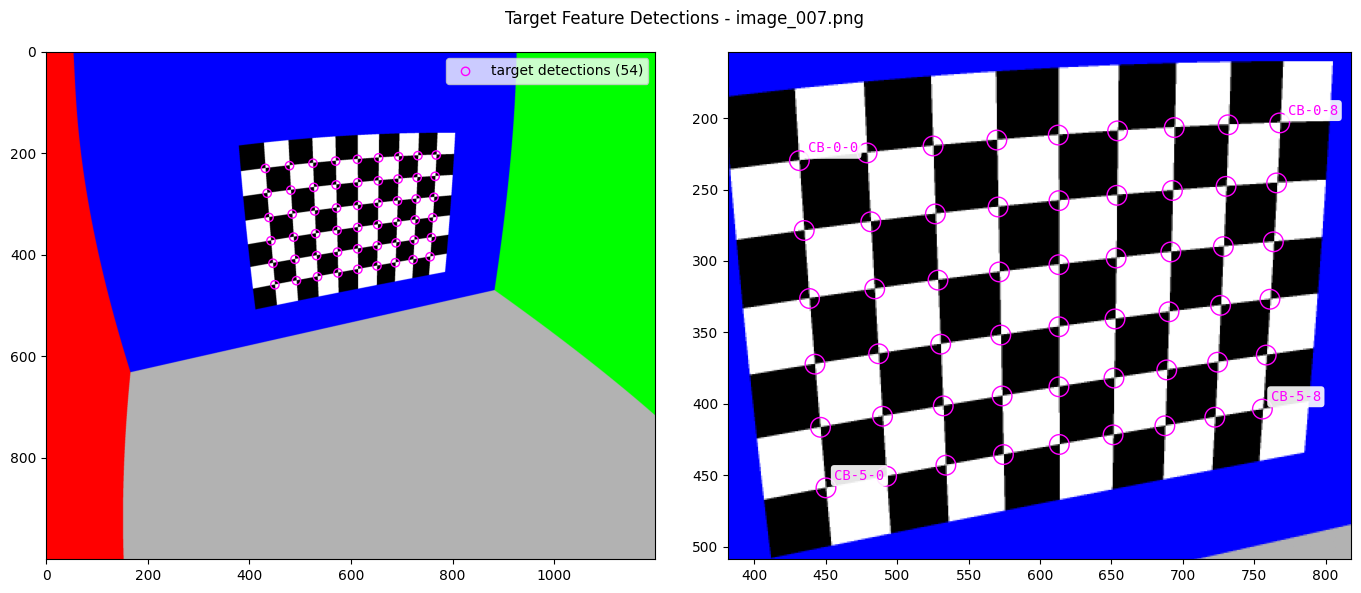

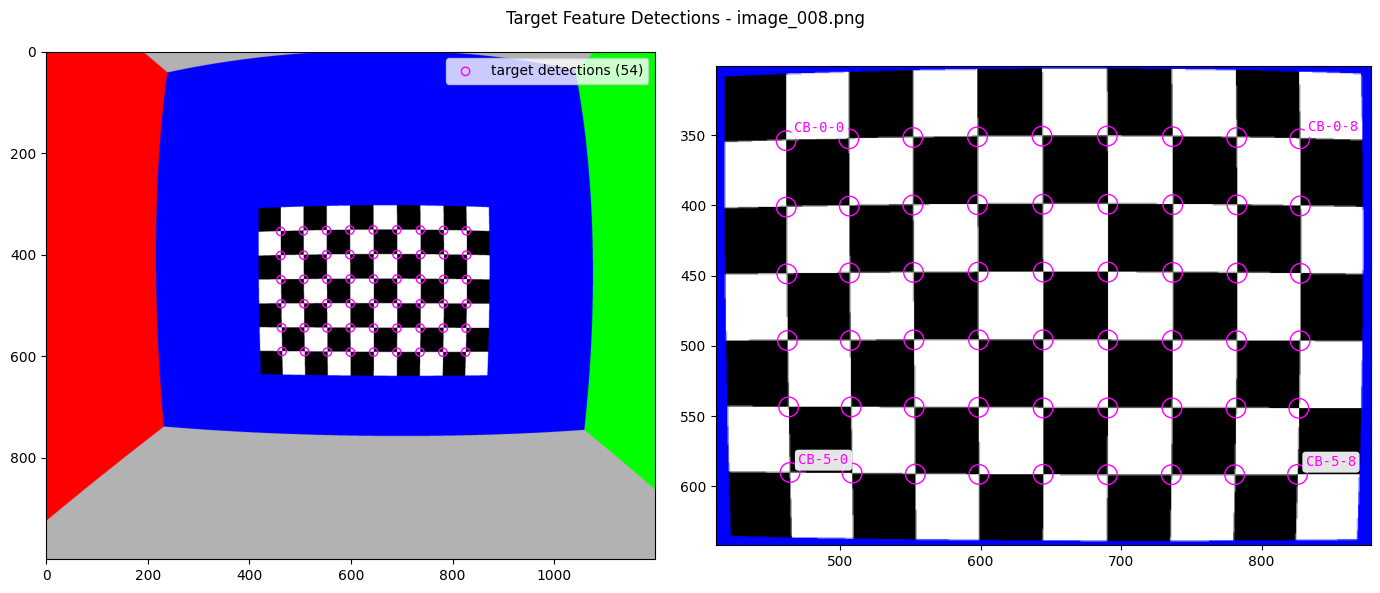

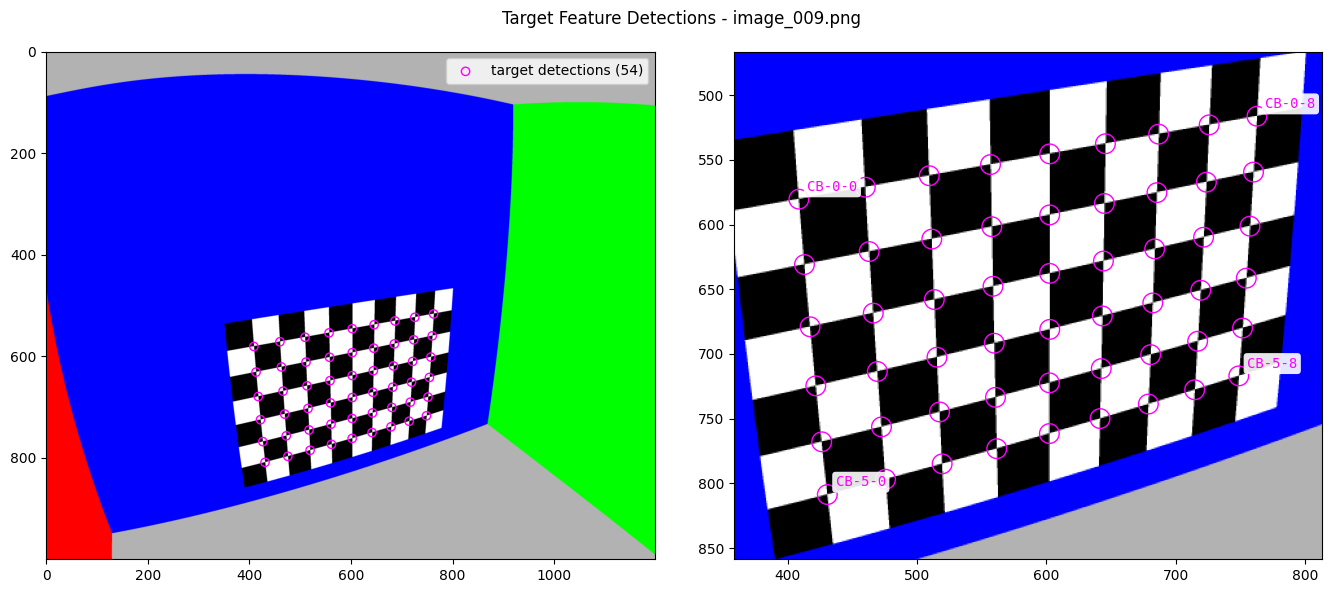

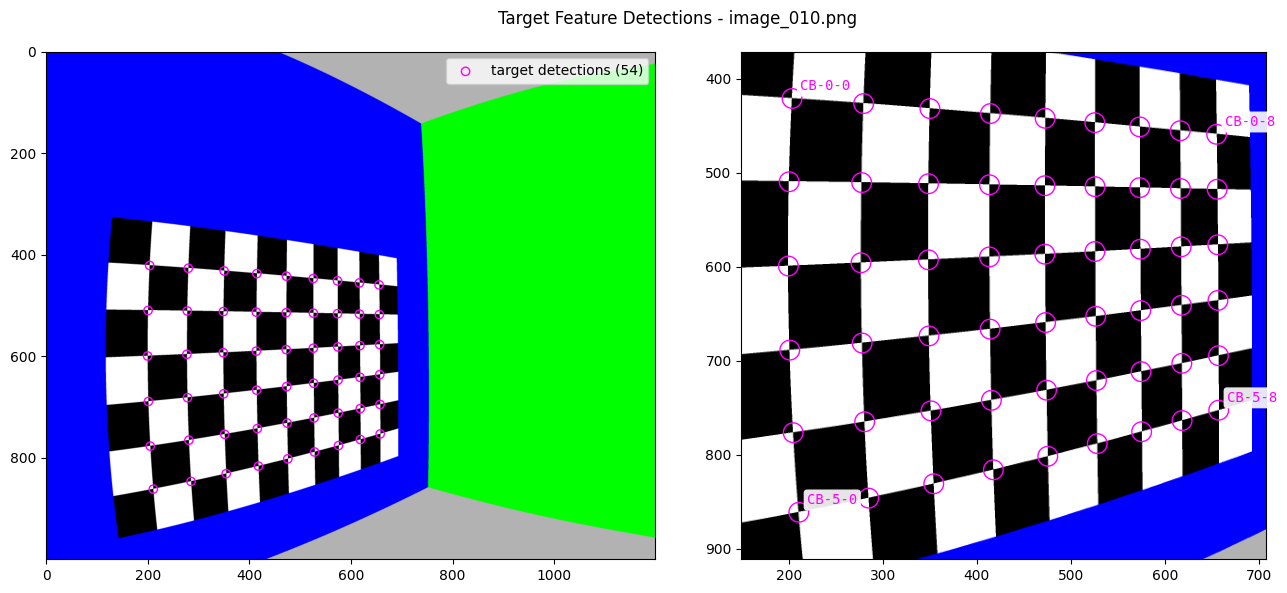

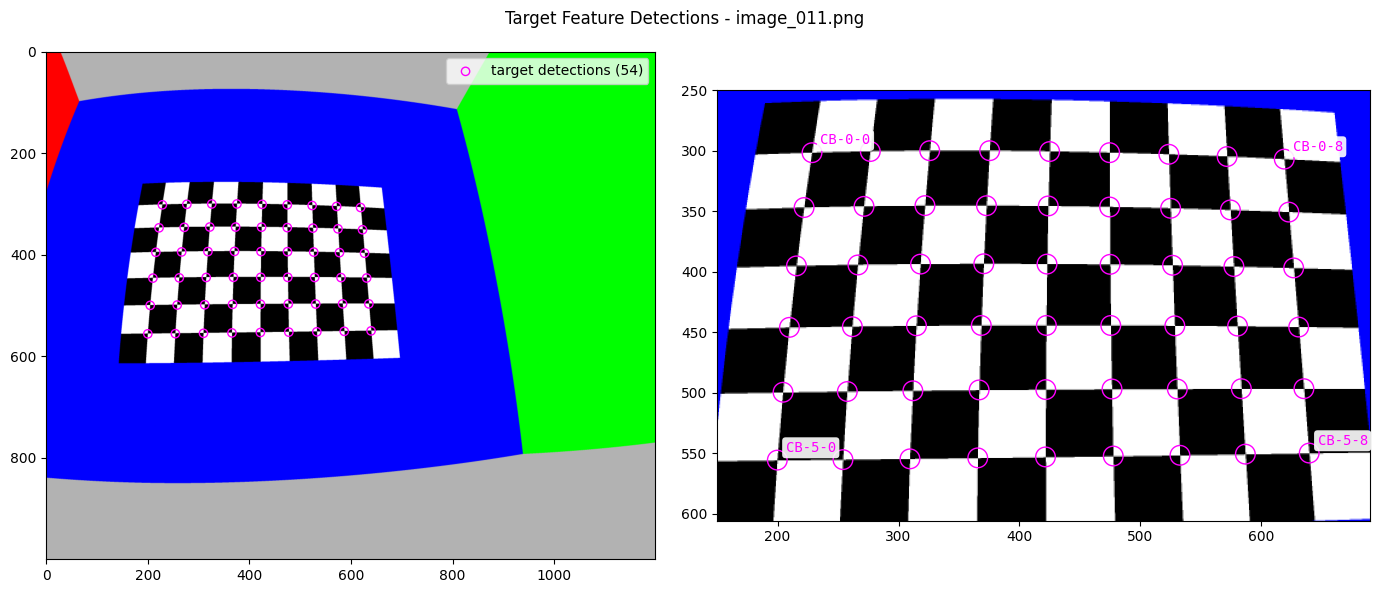

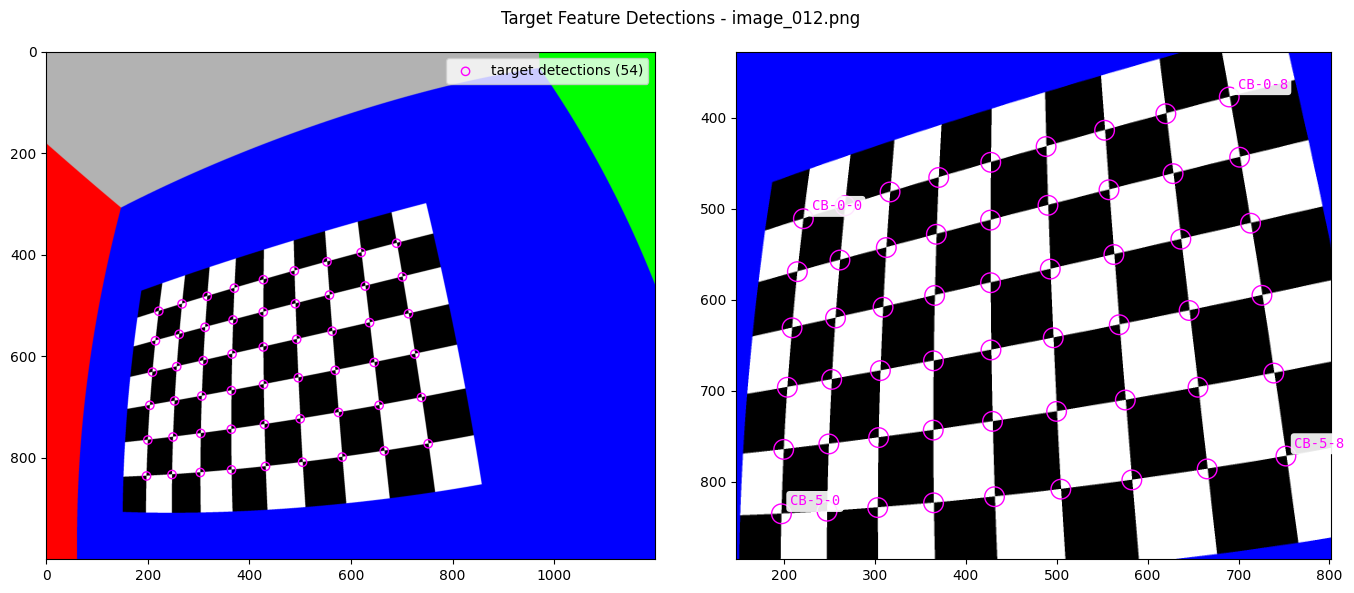

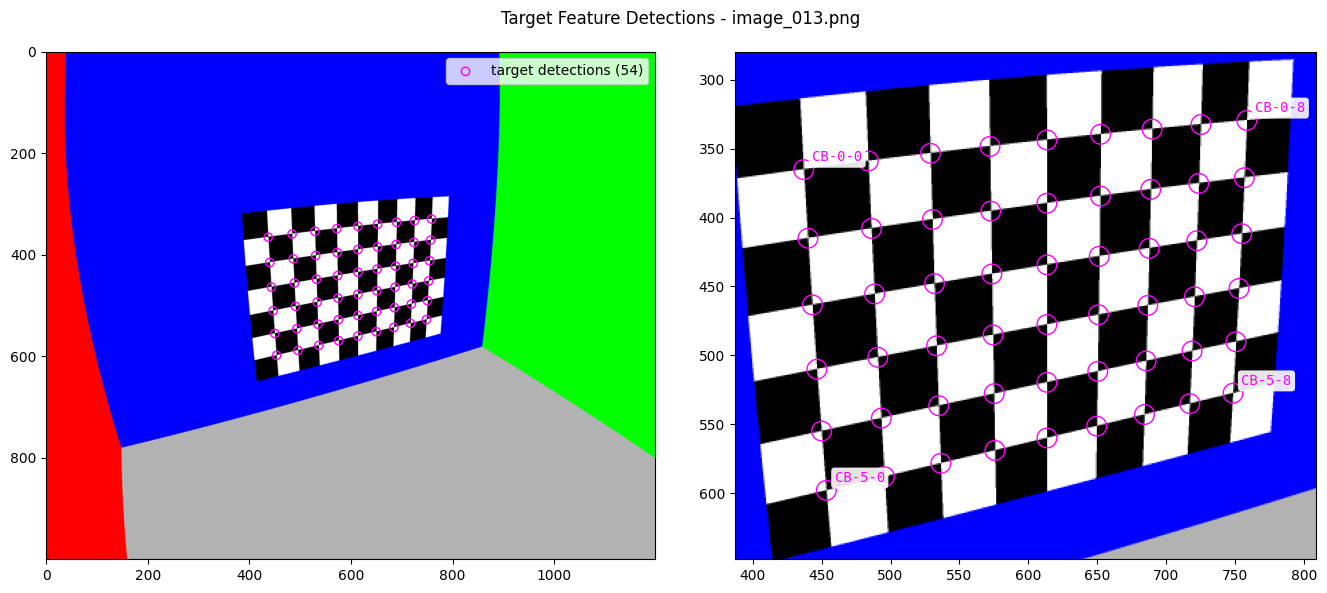

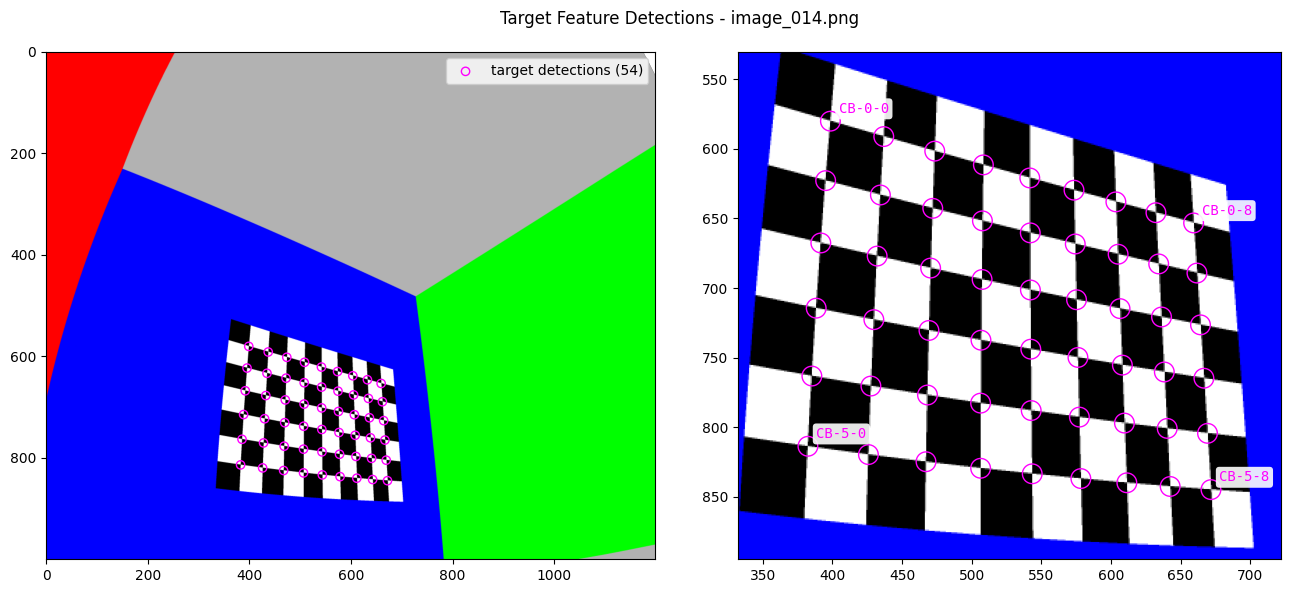

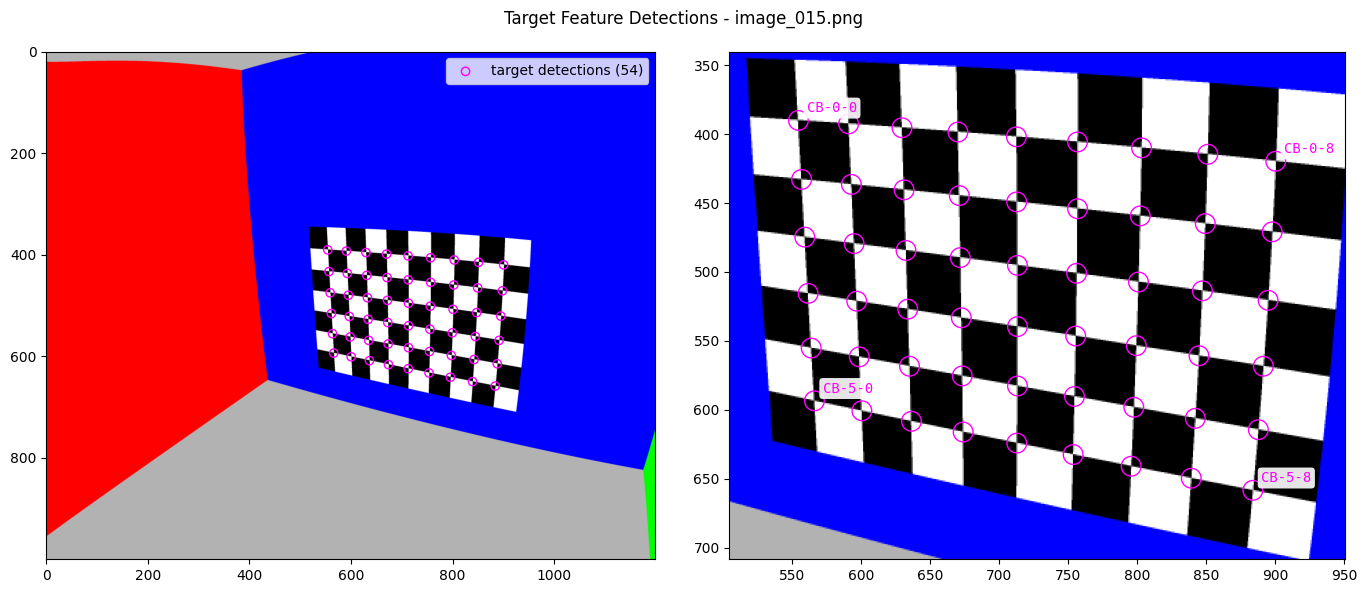

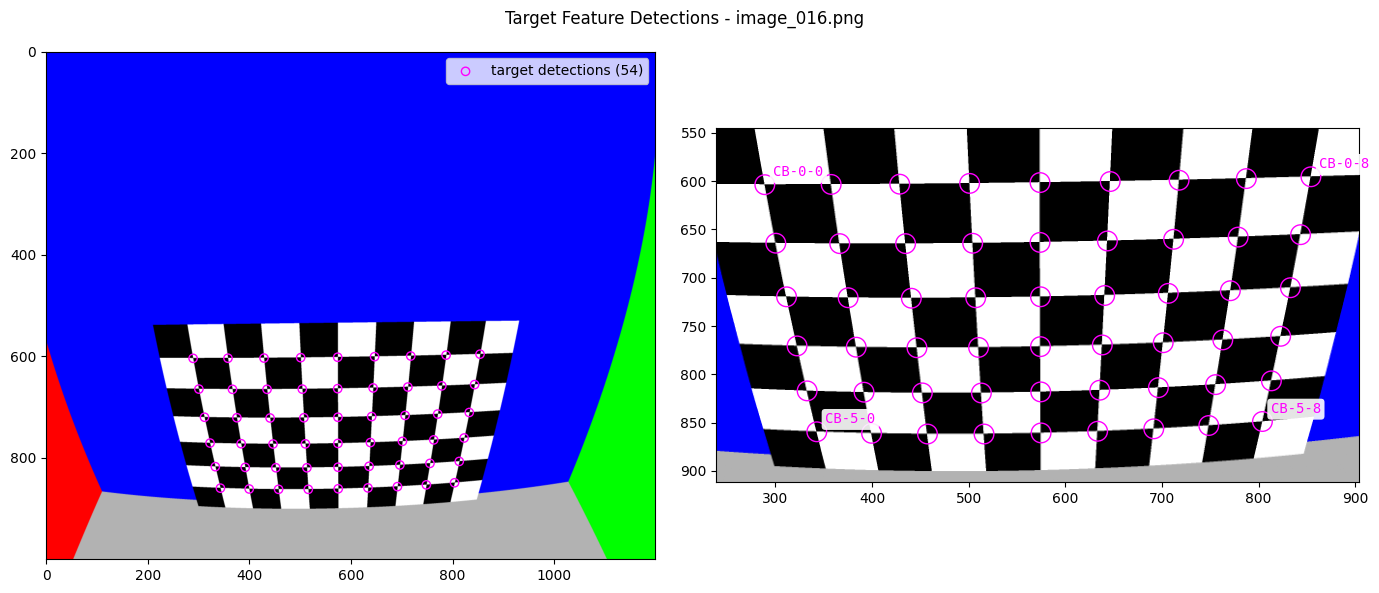

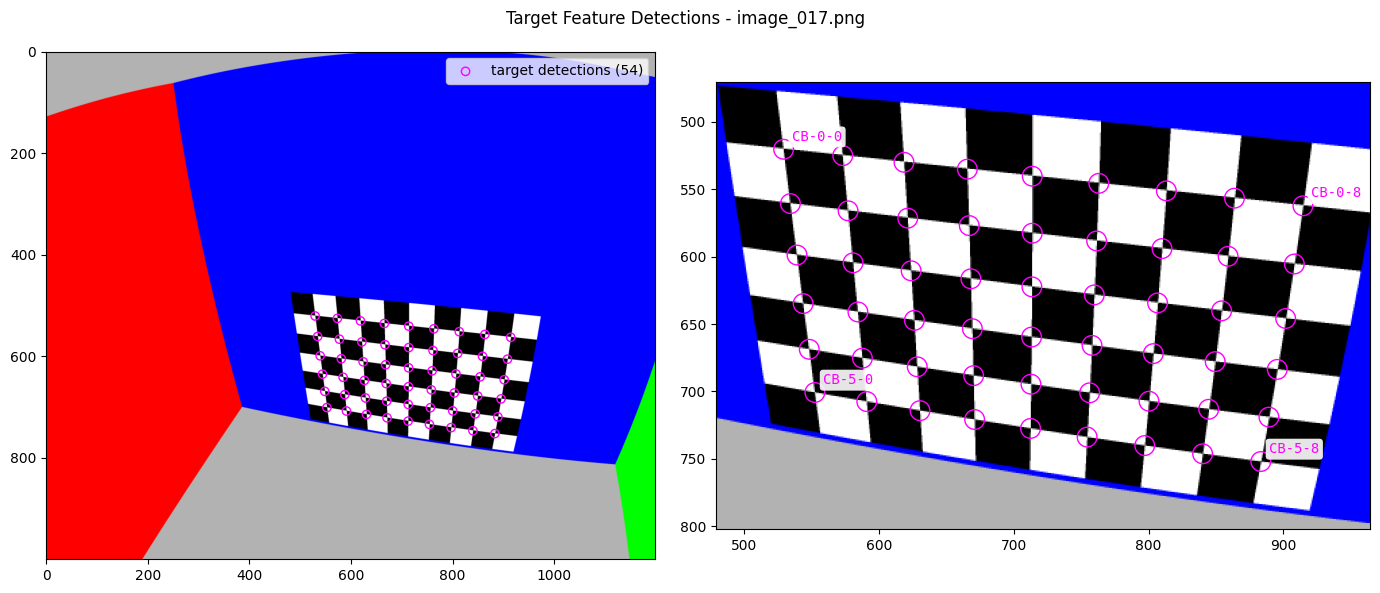

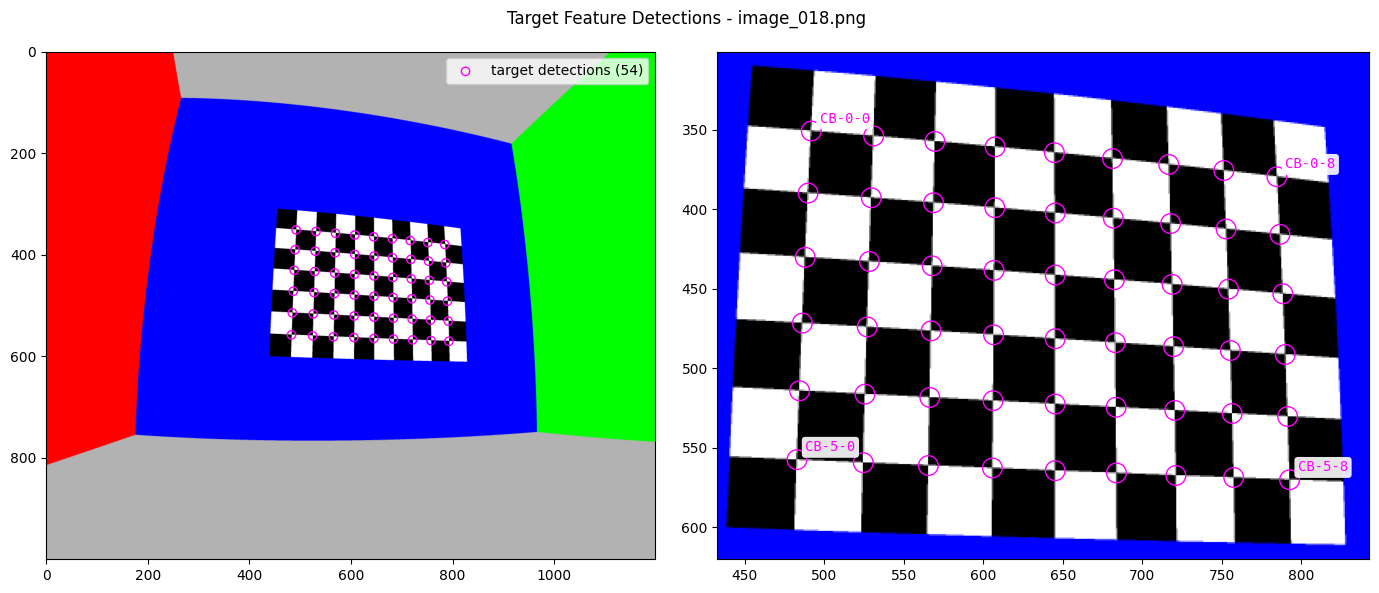

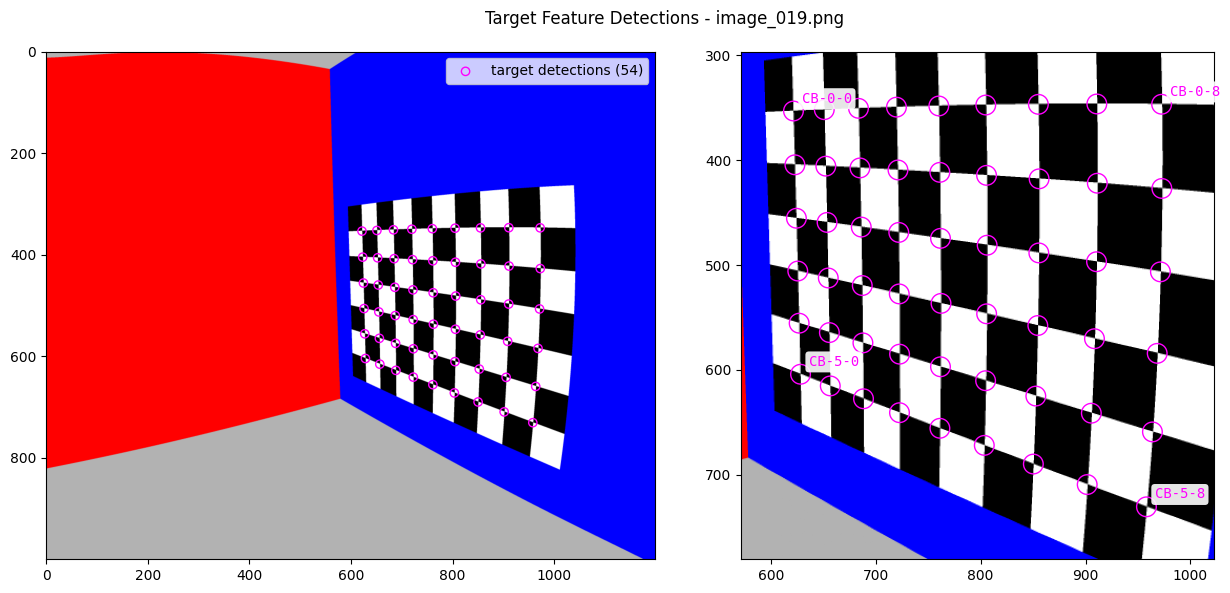

In [22]:
# plot detections

os.makedirs(f"{RESULTS_DIR}/plots", exist_ok=True)

for image_fname in image_fnames:
    image = images[image_fname]
    target_points = target_detections[image_fname]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="tight")
    fig.suptitle(f"Target Feature Detections - {image_fname}")

    # draw detections onto original image
    plot_target_detection(
        image, target_points, ax=axes[0],
        marker_type="o"
    )

    # zoom into calibration target and annotate the four corners
    plot_target_detection(
        image, target_points, ax=axes[1],
        select_keys=None, zoom=True,
        marker_type="o", marker_size=200,
        annotate=True, select_keys_annotate=["CB-0-0", "CB-0-8", "CB-5-0", "CB-5-8"],
        legend=False
    )

    fig.savefig(f"{RESULTS_DIR}/plots/{image_fname.split('.')[0]}.png", bbox_inches="tight")

## Save Results

In [23]:
# save target detections to a CSV (one row per image, one column per feature)

import pandas

results_df = pandas.DataFrame()
results_df["img_fname"] = image_fnames

# get union of all detected feature ID's
all_feature_ids = set()
for detections in target_detections.values():
    all_feature_ids |= set(detections.keys())

all_feature_ids = list(sorted(all_feature_ids))

# write feature detection subpixel locations
for feature_id in all_feature_ids:
    detections = np.array([target_detections[img_fname].get(feature_id, (np.nan, np.nan)) for img_fname in image_fnames])

    results_df[f"{feature_id}.x"] = detections[:,0]
    results_df[f"{feature_id}.y"] = detections[:,1]

results_df.to_csv(f"{DATASET_DIR}/results/target_detection/target_feature_detections.csv", index=False, float_format="%.3f", na_rep=np.nan)

/var/folders/j3/_k92zpq172d0p68rq5kvdbsc0000gn/T/ipykernel_17111/2498639716.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_df[f"{feature_id}.y"] = detections[:,1]
/var/folders/j3/_k92zpq172d0p68rq5kvdbsc0000gn/T/ipykernel_17111/2498639716.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_df[f"{feature_id}.x"] = detections[:,0]
/var/folders/j3/_k92zpq172d0p68rq5kvdbsc0000gn/T/ipykernel_17111/2498639716.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame